In [1]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/ab-test.csv', sep = ',')

df.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     44 non-null     object 
 1   diff    44 non-null     float64
 2   time    44 non-null     object 
 3   group   44 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.5+ KB


In [4]:
df[df['time'] == 'before'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 1 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     22 non-null     object 
 1   diff    22 non-null     float64
 2   time    22 non-null     object 
 3   group   22 non-null     object 
dtypes: float64(1), object(3)
memory usage: 880.0+ bytes


In [5]:
df[df['time'] == 'after'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 0 to 42
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     22 non-null     object 
 1   diff    22 non-null     float64
 2   time    22 non-null     object 
 3   group   22 non-null     object 
dtypes: float64(1), object(3)
memory usage: 880.0+ bytes


In [6]:
ymin = df['diff'].min()
ymax = df['diff'].max() + 10

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_11412\140363990.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_11412\140363990.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


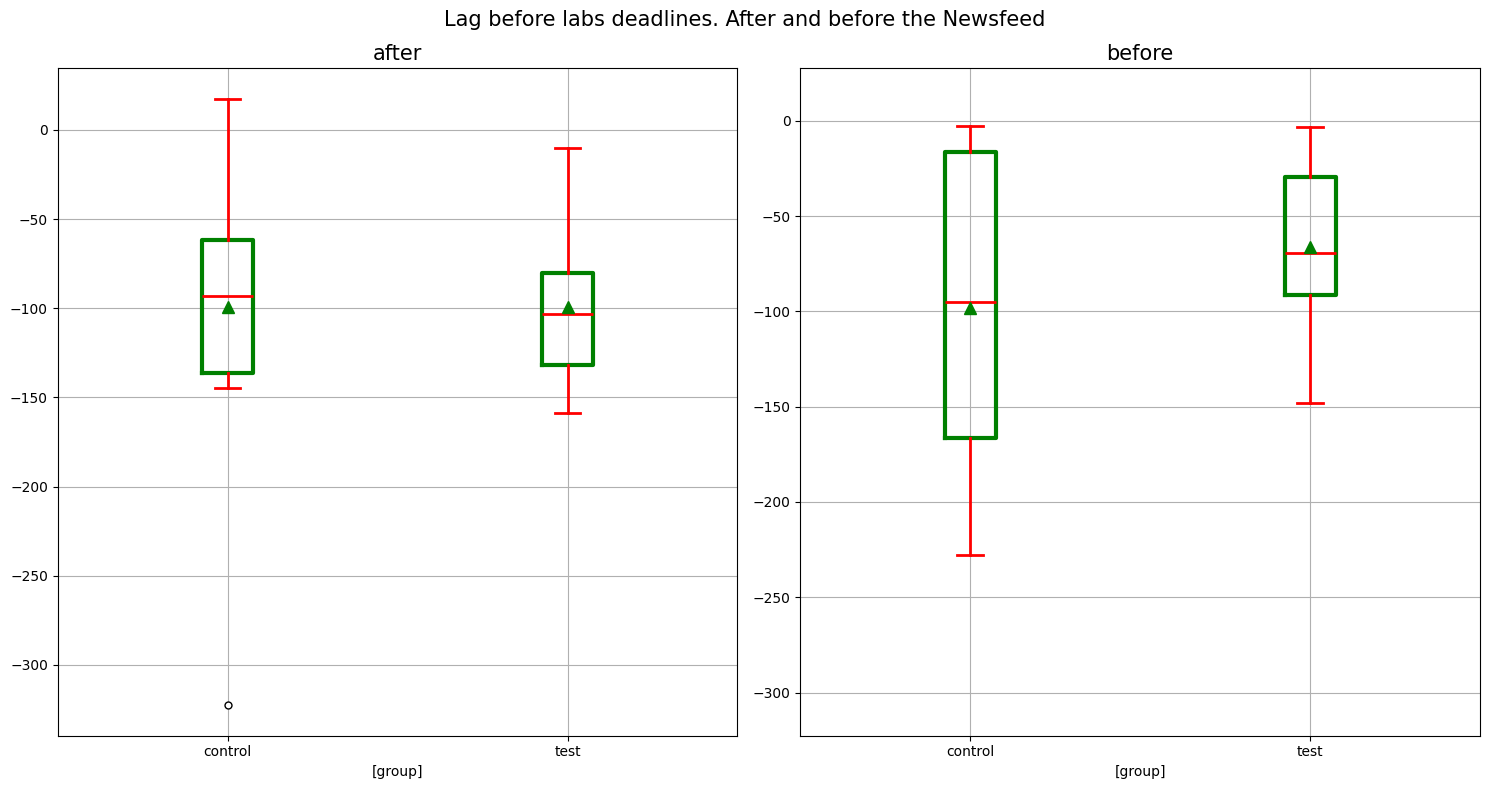

In [ ]:
plt.figure(figsize=(15, 8))
order = ['after', 'before']

for i, t in enumerate(order):
    plt.subplot(1, 2, i + 1)

    data = [
        df.loc[(df['group'] == 'control') & (df['time'] == t), 'diff'],
        df.loc[(df['group'] == 'test') & (df['time'] == t), 'diff']
    ]

    plt.boxplot(
        data,
        labels=['control', 'test'],
        boxprops=dict(color='green', linewidth=3),
        whiskerprops=dict(color='red', linewidth=2),    # усы
        capprops=dict(color='red', linewidth=2),        # линии в конце усов
        medianprops=dict(color='red', linewidth=2),     # медиана
        flierprops=dict(marker='o', markerfacecolor='white', markersize=5, linestyle='none'),  # выбросы 
        showmeans=True,
        meanprops=dict(marker='^', markerfacecolor='green', markeredgecolor='green', markersize=8)
    )

    plt.title(t, fontsize=15)
    plt.xlabel('[group]')
    plt.grid(True)

plt.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.ylim(ymin, ymax)
plt.tight_layout()
plt.show()


Каков был межквартильный размах контрольной группы до появления новостей?

- 150

In [8]:
conn.close

NameError: name 'conn' is not defined